# NetworkX for GPS Navigation
A graph can be used to represent street maps.
- Intersections are represented by **Nodes**
- Streets are represented by **Edges**

## Other Helpful Libraries and APIs
**OpenStreetMapNX** (osmnx) is a library 

In [1]:
import networkx as nx
import osmnx as ox

ox.__version__

'2.1.0'

In [ ]:
def m_to_mi(m):
    #       m to cm  to in  to ft to mi
    return (m * 100) / 2.54 / 12 / 5280

def sec_to_min(sec):
    return sec / 60

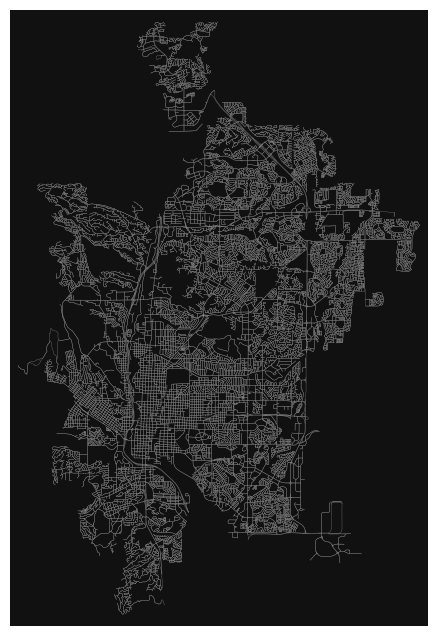

In [2]:
ox.settings.bidirectional_network_types += "drive"
G = ox.graph.graph_from_place("Colorado Springs, Colorado, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G, edge_linewidth=.2, node_size=0)

In [3]:
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

In [4]:
# UCCS
orig = ox.distance.nearest_nodes(G, X=-104.80079959955438, Y=38.89284009494745)
# Airport
dest = ox.distance.nearest_nodes(G, X=-104.7114257661276, Y=38.80484732844506)

## Shortest Travel Time

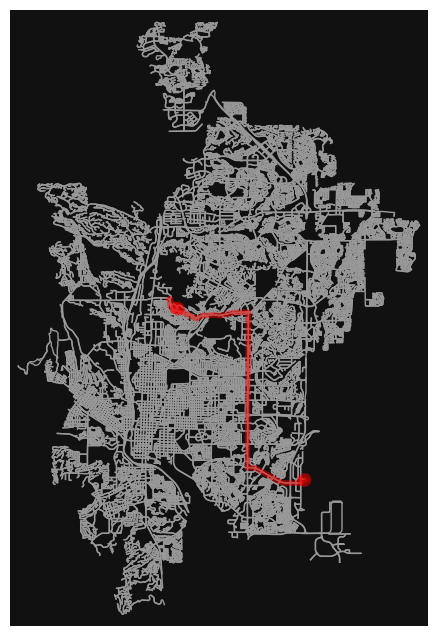

In [5]:
# find the shortest path between nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [6]:
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
travel_m = round(sum(edge_lengths))
# meters to miles
travel_mi = m_to_mi(travel_m)
print(f"{travel_mi:.2f} Miles")

11.34 Miles


In [7]:
travel_secs = sum(ox.routing.route_to_gdf(G, route)["travel_time"])
travel_mins = sec_to_min(travel_secs)
print(f"{travel_mins:.2f} Minutes")

19.03 Minutes


## Shortest Travel Distance

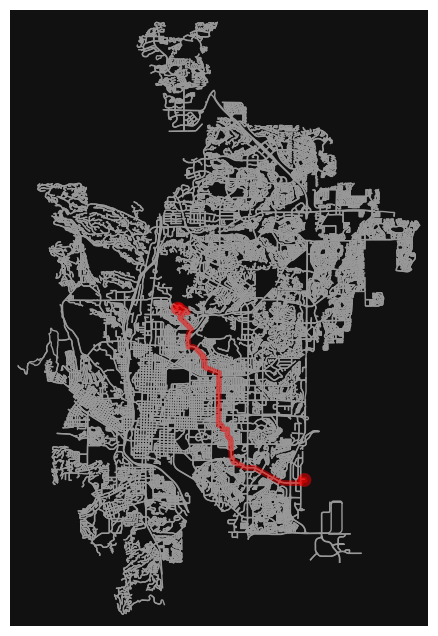

In [8]:
# find the shortest path between nodes, minimizing distance, then plot it
route = ox.routing.shortest_path(G, orig, dest)
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [9]:
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
travel_m = round(sum(edge_lengths))
# meters to miles
travel_mi = m_to_mi(travel_m)
print(f"{travel_mi:.2f} Miles")

10.09 Miles


In [10]:
travel_secs = sum(ox.routing.route_to_gdf(G, route)["travel_time"])
travel_mins = sec_to_min(travel_secs)
print(f"{travel_mins:.2f} Minutes")

21.48 Minutes


# The Shortest Distance Algorithm